#  Análisis Exploratorio de Datos (EDA)
## YouToxic Dataset - 1000 Comentarios de YouTube

**Autor:** [Tu nombre aquí]  
**Fecha:** 2024  
**Objetivo:** Entender la estructura y características del dataset antes de preprocesar

---

##  ¿Qué vamos a hacer?

En este notebook vamos a:
1. ✅ Cargar el dataset
2. ✅ Explorar su estructura
3. ✅ Analizar estadísticas básicas
4. ✅ Visualizar con gráficos
5. ✅ Encontrar patrones y problemas

---


In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración visual
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [3]:
# Cargar el dataset
df = pd.read_csv('../data/raw/youtoxic_original.csv')

print(" Dataset cargado correctamente")
print(f"\n Dimensiones: {df.shape[0]:,} comentarios × {df.shape[1]} columnas")

 Dataset cargado correctamente

 Dimensiones: 1,000 comentarios × 15 columnas


In [4]:
# Ver las primeras filas
print("="*80)
print("📋 PRIMERAS 5 FILAS DEL DATASET")
print("="*80)
print(df.head())

📋 PRIMERAS 5 FILAS DEL DATASET
              CommentId      VideoId  \
0  Ugg2KwwX0V8-aXgCoAEC  04kJtp6pVXI   
1  Ugg2s5AzSPioEXgCoAEC  04kJtp6pVXI   
2  Ugg3dWTOxryFfHgCoAEC  04kJtp6pVXI   
3  Ugg7Gd006w1MPngCoAEC  04kJtp6pVXI   
4  Ugg8FfTbbNF8IngCoAEC  04kJtp6pVXI   

                                                Text  IsToxic  IsAbusive  \
0  If only people would just take a step back and...    False      False   
1  Law enforcement is not trained to shoot to app...     True       True   
2  \r\nDont you reckon them 'black lives matter' ...     True       True   
3  There are a very large number of people who do...    False      False   
4  The Arab dude is absolutely right, he should h...    False      False   

   IsThreat  IsProvocative  IsObscene  IsHatespeech  IsRacist  IsNationalist  \
0     False          False      False         False     False          False   
1     False          False      False         False     False          False   
2     False          False     

In [5]:
# Ver información del dataset
print("="*80)
print("INFORMACIÓN DEL DATASET")
print("="*80)
print(df.info())

print("\n" + "="*80)
print(" VALORES FALTANTES")
print("="*80)
print(df.isnull().sum())

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB
None

 VALORES FALTANTES
CommentId          0
VideoId 

In [6]:
# Analizar la columna IsToxic
print("="*80)
print(" DISTRIBUCIÓN DE CLASES (IsToxic)")
print("="*80)

# Contar valores
conteos = df['IsToxic'].value_counts()
print("\n CONTEOS:")
print(conteos)

# Porcentajes
porcentajes = df['IsToxic'].value_counts(normalize=True) * 100
print("\n PORCENTAJES:")
for clase, pct in porcentajes.items():
    nombre = "TÓXICO" if clase else "NORMAL"
    print(f"  {nombre}: {pct:.1f}%")

# Resumen
print("\n RESUMEN:")
print(f"  Comentarios NORMALES (False): {conteos[False]:,}")
print(f"  Comentarios TÓXICOS (True):   {conteos[True]:,}")

 DISTRIBUCIÓN DE CLASES (IsToxic)

 CONTEOS:
IsToxic
False    538
True     462
Name: count, dtype: int64

 PORCENTAJES:
  NORMAL: 53.8%
  TÓXICO: 46.2%

 RESUMEN:
  Comentarios NORMALES (False): 538
  Comentarios TÓXICOS (True):   462


# ANALIZAMOS TODAS LAS COLUMNAS PARA VER COMO ESTAN BALANCEADAS

In [7]:
# Analizar TODAS las columnas de clasificación 
print("="*80)
print("📊 ANÁLISIS DE BALANCE - TODAS LAS COLUMNAS")
print("="*80)

# Columnas a analizar
columnas_clasificacion = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 
                          'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 
                          'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

# Analizar cada columna
for columna in columnas_clasificacion:
    conteos = df[columna].value_counts()
    porcentajes = df[columna].value_counts(normalize=True) * 100
    
    print(f"\n{'='*40}")
    print(f"📌 {columna}")
    print(f"{'='*40}")
    
    # Contar False
    count_false = conteos.get(False, 0)
    pct_false = porcentajes.get(False, 0)
    print(f"  False (Normal):  {count_false:4} ({pct_false:5.1f}%)")
    
    # Contar True
    count_true = conteos.get(True, 0)
    pct_true = porcentajes.get(True, 0)
    print(f"  True (Positivo): {count_true:4} ({pct_true:5.1f}%)")
    
    # Calcular ratio
    if count_true > 0 and count_false > 0:
        ratio = max(count_false, count_true) / min(count_false, count_true)
        print(f"  Balance ratio:   {ratio:.2f}x")
    else:
        print(f"  Balance ratio:   ⚠️ Muy desbalanceado (sin datos True o False)")

📊 ANÁLISIS DE BALANCE - TODAS LAS COLUMNAS

📌 IsToxic
  False (Normal):   538 ( 53.8%)
  True (Positivo):  462 ( 46.2%)
  Balance ratio:   1.16x

📌 IsAbusive
  False (Normal):   647 ( 64.7%)
  True (Positivo):  353 ( 35.3%)
  Balance ratio:   1.83x

📌 IsThreat
  False (Normal):   979 ( 97.9%)
  True (Positivo):   21 (  2.1%)
  Balance ratio:   46.62x

📌 IsProvocative
  False (Normal):   839 ( 83.9%)
  True (Positivo):  161 ( 16.1%)
  Balance ratio:   5.21x

📌 IsObscene
  False (Normal):   900 ( 90.0%)
  True (Positivo):  100 ( 10.0%)
  Balance ratio:   9.00x

📌 IsHatespeech
  False (Normal):   862 ( 86.2%)
  True (Positivo):  138 ( 13.8%)
  Balance ratio:   6.25x

📌 IsRacist
  False (Normal):   875 ( 87.5%)
  True (Positivo):  125 ( 12.5%)
  Balance ratio:   7.00x

📌 IsNationalist
  False (Normal):   992 ( 99.2%)
  True (Positivo):    8 (  0.8%)
  Balance ratio:   124.00x

📌 IsSexist
  False (Normal):   999 ( 99.9%)
  True (Positivo):    1 (  0.1%)
  Balance ratio:   999.00x

📌 IsHomop

##  Selección de Columnas Target para el Proyecto

###  Análisis de Balance de Clases

Después de analizar todas las 12 columnas de clasificación, he decidido trabajar con las **5 columnas mejor balanceadas**:

###  Columnas Seleccionadas

#### 1. **IsToxic** (PRINCIPAL)
- **False:** 538 comentarios (53.8%)
- **True:** 462 comentarios (46.2%)
- **Balance Ratio:** 1.16x ⭐ EXCELENTE
- **Uso:** Todos los niveles (Esencial, Medio, Avanzado, Experto)
- **Razón:** Balance casi perfecto, ideal para modelo base

#### 2. **IsAbusive** (SECUNDARIA)
- **False:** 647 comentarios (64.7%)
- **True:** 353 comentarios (35.3%)
- **Balance Ratio:** 1.83x ⭐ BUENO
- **Uso:** Modelos multi-etiqueta (Medio+)
- **Razón:** Balance aceptable, complementa IsToxic bien

#### 3. **IsProvocative** (OPCIONAL)
- **False:** 839 comentarios (83.9%)
- **True:** 161 comentarios (16.1%)
- **Balance Ratio:** 5.21x ⚠️ MODERADO
- **Uso:** Modelos multi-etiqueta con técnicas de balanceo (Medio+)
- **Razón:** Usaremos `class_weight='balanced'` para manejar el desbalance

#### 4. **IsObscene** (OPCIONAL)
- **False:** 900 comentarios (90.0%)
- **True:** 100 comentarios (10.0%)
- **Balance Ratio:** 9.00x ⚠️ MODERADO
- **Uso:** Modelos multi-etiqueta con técnicas de balanceo (Medio+)
- **Razón:** Usaremos `class_weight='balanced'` para manejar el desbalance

#### 5. **IsHatespeech** (OPCIONAL)
- **False:** 862 comentarios (86.2%)
- **True:** 138 comentarios (13.8%)
- **Balance Ratio:** 6.25x ⚠️ MODERADO
- **Uso:** Modelos multi-etiqueta con técnicas de balanceo (Medio+)
- **Razón:** Usaremos `class_weight='balanced'` para manejar el desbalance

#### 6. **IsRacist** (OPCIONAL)
- **False:** 875 comentarios (87.5%)
- **True:** 125 comentarios (12.5%)
- **Balance Ratio:** 7.00x ⚠️ MODERADO
- **Uso:** Modelos multi-etiqueta con técnicas de balanceo (Medio+)
- **Razón:** Usaremos `class_weight='balanced'` para manejar el desbalance

### ❌ Columnas Descartadas

Las siguientes columnas fueron descartadas por estar **MUY DESBALANCEADAS** (ratio > 46x) o **sin datos**:

| Columna | False | True | Ratio | Razón |
|---------|-------|------|-------|-------|
| IsThreat | 979 (97.9%) | 21 (2.1%) | 46.62x | Muy desbalanceado |
| IsNationalist | 992 (99.2%) | 8 (0.8%) | 124x | Extremadamente desbalanceado |
| IsReligiousHate | 988 (98.8%) | 12 (1.2%) | 82.33x | Extremadamente desbalanceado |
| IsHomophobic | 1000 (100%) | 0 (0%) | N/A | Sin datos positivos |
| IsRadicalism | 1000 (100%) | 0 (0%) | N/A | Sin datos positivos |

###  Técnicas de Balanceo que Usaremos

**Para manejar el desbalance en las columnas moderadas:**

1. **class_weight='balanced'** en los modelos
   - Línea de código simple
   - Le da más peso a la clase minoritaria
   - Se aplica en el entrenamiento, no modifica el dataset

2. **Data Augmentation en Preprocesamiento**
   - Back-translation (traducir y volver)
   - Reemplazo por sinónimos
   - Genera nuevos textos reales con sentido

3. **Train/Test Split PRIMERO**
   - Dividimos antes de cualquier augmentation
   - Evita data leakage
   - Métricas más confiables




In [8]:
# Analizar características del texto
print("="*80)
print("📝 ANÁLISIS DEL TEXTO")
print("="*80)

# Calcular longitudes
df['longitud_caracteres'] = df['Text'].astype(str).str.len()
df['num_palabras'] = df['Text'].astype(str).str.split().str.len()

# Estadísticas generales
print("\n📏 LONGITUD EN CARACTERES:")
print(df['longitud_caracteres'].describe())

print("\n\n📚 NÚMERO DE PALABRAS:")
print(df['num_palabras'].describe())

# Ejemplos
print("\n" + "="*80)
print("🔎 EJEMPLOS DE COMENTARIOS")
print("="*80)

print("\n✅ Comentario NORMAL más corto:")
idx_corto_normal = df[(df['IsToxic']==False)]['longitud_caracteres'].idxmin()
print(f"Texto: {df.loc[idx_corto_normal, 'Text']}")
print(f"Longitud: {df.loc[idx_corto_normal, 'longitud_caracteres']} caracteres")

print("\n💔 Comentario TÓXICO más corto:")
idx_corto_toxico = df[(df['IsToxic']==True)]['longitud_caracteres'].idxmin()
print(f"Texto: {df.loc[idx_corto_toxico, 'Text']}")
print(f"Longitud: {df.loc[idx_corto_toxico, 'longitud_caracteres']} caracteres")

print("\n✅ Comentario NORMAL más largo (primeros 150 caracteres):")
idx_largo_normal = df[(df['IsToxic']==False)]['longitud_caracteres'].idxmax()
print(f"Texto: {df.loc[idx_largo_normal, 'Text'][:150]}...")
print(f"Longitud: {df.loc[idx_largo_normal, 'longitud_caracteres']} caracteres")

print("\n💔 Comentario TÓXICO más largo (primeros 150 caracteres):")
idx_largo_toxico = df[(df['IsToxic']==True)]['longitud_caracteres'].idxmax()
print(f"Texto: {df.loc[idx_largo_toxico, 'Text'][:150]}...")
print(f"Longitud: {df.loc[idx_largo_toxico, 'longitud_caracteres']} caracteres")

📝 ANÁLISIS DEL TEXTO

📏 LONGITUD EN CARACTERES:
count    1000.000000
mean      185.953000
std       272.294861
min         3.000000
25%        47.000000
50%       102.000000
75%       217.000000
max      4474.000000
Name: longitud_caracteres, dtype: float64


📚 NÚMERO DE PALABRAS:
count    1000.000000
mean       33.776000
std        49.069498
min         1.000000
25%         9.000000
50%        19.000000
75%        39.000000
max       815.000000
Name: num_palabras, dtype: float64

🔎 EJEMPLOS DE COMENTARIOS

✅ Comentario NORMAL más corto:
Texto: wtf
Longitud: 3 caracteres

💔 Comentario TÓXICO más corto:
Texto: Idiots
Longitud: 6 caracteres

✅ Comentario NORMAL más largo (primeros 150 caracteres):
Texto: *WHAT DOES TRAYVON MARTIN AND MICHAEL BROWN HAVE IN COMMON?*  
*THE REAL REASON BEHIND THE RIOTS THAT NO ONE DARE SPEAK OF.*

As with the Zimmerman...
Longitud: 2315 caracteres

💔 Comentario TÓXICO más largo (primeros 150 caracteres):
Texto: THE UGLY TRUTH:

If you talk like a THUG, act 

In [9]:
# Comparar características para TODAS las columnas target
print("="*80)
print(" COMPARACIÓN DE CARACTERÍSTICAS POR TODAS LAS COLUMNAS TARGET")
print("="*80)

# Columnas target seleccionadas
columnas_target = ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech']

# Analizar cada columna
for columna in columnas_target:
    print(f"\n{'='*80}")
    print(f"🏷️  {columna}")
    print(f"{'='*80}")
    
    # Dividir por clase
    normal = df[df[columna] == False]
    positivo = df[df[columna] == True]
    
    print(f"\n✅ {columna}=False")
    print(f"  Cantidad: {len(normal):4}")
    print(f"  Longitud promedio: {normal['longitud_caracteres'].mean():7.0f} caracteres")
    print(f"  Palabras promedio: {normal['num_palabras'].mean():7.0f} palabras")
    
    print(f"\n💔 {columna}=True")
    print(f"  Cantidad: {len(positivo):4}")
    print(f"  Longitud promedio: {positivo['longitud_caracteres'].mean():7.0f} caracteres")
    print(f"  Palabras promedio: {positivo['num_palabras'].mean():7.0f} palabras")
    
    # Diferencias
    diff_char = positivo['longitud_caracteres'].mean() - normal['longitud_caracteres'].mean()
    diff_palabras = positivo['num_palabras'].mean() - normal['num_palabras'].mean()
    
    print(f"\n🔍 Diferencias:")
    print(f"  Caracteres: {diff_char:+.0f} ({diff_char/normal['longitud_caracteres'].mean()*100:+.1f}%)")
    print(f"  Palabras:   {diff_palabras:+.0f} ({diff_palabras/normal['num_palabras'].mean()*100:+.1f}%)")

 COMPARACIÓN DE CARACTERÍSTICAS POR TODAS LAS COLUMNAS TARGET

🏷️  IsToxic

✅ IsToxic=False
  Cantidad:  538
  Longitud promedio:     183 caracteres
  Palabras promedio:      33 palabras

💔 IsToxic=True
  Cantidad:  462
  Longitud promedio:     190 caracteres
  Palabras promedio:      35 palabras

🔍 Diferencias:
  Caracteres: +7 (+3.9%)
  Palabras:   +2 (+4.7%)

🏷️  IsAbusive

✅ IsAbusive=False
  Cantidad:  647
  Longitud promedio:     196 caracteres
  Palabras promedio:      35 palabras

💔 IsAbusive=True
  Cantidad:  353
  Longitud promedio:     168 caracteres
  Palabras promedio:      31 palabras

🔍 Diferencias:
  Caracteres: -28 (-14.3%)
  Palabras:   -5 (-13.0%)

🏷️  IsProvocative

✅ IsProvocative=False
  Cantidad:  839
  Longitud promedio:     187 caracteres
  Palabras promedio:      34 palabras

💔 IsProvocative=True
  Cantidad:  161
  Longitud promedio:     183 caracteres
  Palabras promedio:      33 palabras

🔍 Diferencias:
  Caracteres: -4 (-2.1%)
  Palabras:   -1 (-1.6%)

🏷️  

## 📝 Análisis de Características del Texto - 5 Columnas Target

### 📏 Estadísticas Generales de TODO el Dataset

**Longitud en Caracteres:**
- Media: 185.5 caracteres
- Desviación estándar: 270.8
- Rango: 3 - 4421 caracteres
- Cuartiles: 25% (47) | 50% (101) | 75% (217)

**Número de Palabras:**
- Media: 33.8 palabras
- Desviación estándar: 49.1
- Rango: 1 - 815 palabras
- Cuartiles: 25% (9) | 50% (19) | 75% (39)

### 🔍 Comparación Detallada: False vs True para Cada Target

#### 1. **IsToxic**
| Métrica | False | True | Diferencia |
|---------|-------|------|-----------|
| Cantidad | 538 | 462 | - |
| Longitud promedio | 182 | 189 | +7 (+3.9%) |
| Palabras promedio | 33 | 35 | +2 (+4.7%) |

**Patrón:** Los comentarios TÓXICOS son ligeramente más largos (+3.9%)

#### 2. **IsAbusive**
| Métrica | False | True | Diferencia |
|---------|-------|------|-----------|
| Cantidad | 647 | 353 | - |
| Longitud promedio | 195 | 168 | -28 (-14.2%) |
| Palabras promedio | 35 | 31 | -5 (-13.0%) |

**Patrón:** Los comentarios ABUSIVOS son SIGNIFICATIVAMENTE MÁS CORTOS (-14.2%) ⬇️

#### 3. **IsProvocative**
| Métrica | False | True | Diferencia |
|---------|-------|------|-----------|
| Cantidad | 839 | 161 | - |
| Longitud promedio | 186 | 182 | -4 (-2.1%) |
| Palabras promedio | 34 | 33 | -1 (-1.6%) |

**Patrón:** Casi NO HAY diferencia (-2.1%) - Necesitará otras características

#### 4. **IsObscene**
| Métrica | False | True | Diferencia |
|---------|-------|------|-----------|
| Cantidad | 900 | 100 | - |
| Longitud promedio | 180 | 236 | +56 (+31.2%) |
| Palabras promedio | 33 | 44 | +11 (+35.0%) |

**Patrón:** Los comentarios OBSCENOS son MUCHO MÁS LARGOS (+31.2%) ⬆️⬆️

#### 5. **IsHatespeech**
| Métrica | False | True | Diferencia |
|---------|-------|------|-----------|
| Cantidad | 862 | 138 | - |
| Longitud promedio | 174 | 260 | +86 (+49.7%) |
| Palabras promedio | 32 | 47 | +15 (+48.7%) |

**Patrón:** Los comentarios DE ODIO son EXTREMADAMENTE MÁS LARGOS (+49.7%) ⬆️⬆️⬆️

### 📊 Resumen Comparativo de Todas las 5 Columnas

| Columna | Diferencia Caracteres | Patrón | Distintividad |
|---------|----------------------|--------|---------------|
| **IsToxic** | +7 (+3.9%) | Ligeramente más largo | Media |
| **IsAbusive** | -28 (-14.2%) | MÁS CORTO | Alta |
| **IsProvocative** | -4 (-2.1%) | Casi igual | Baja |
| **IsObscene** | +56 (+31.2%) | MÁS LARGO | Muy Alta |
| **IsHatespeech** | +86 (+49.7%) | EXTREMADAMENTE MÁS LARGO | Máxima ⭐ |

### 💡 Insights Clave por Columna

1. **IsHatespeech ⭐ MEJOR PREDICTOR**
   - +49.7% más largo
   - Patrón muy distintivo
   - Los comentarios de odio desarrollan argumentos largos

2. **IsObscene - PATRÓN CLARO**
   - +31.2% más largo
   - Diferencia significativa
   - Comentarios obscenos son más extensos

3. **IsAbusive - PATRÓN INVERSO**
   - -14.2% más CORTO
   - Comentarios abusivos tienden a ser breves
   - Patrón interesante y distintivo

4. **IsToxic - PATRÓN DÉBIL**
   - +3.9% más largo
   - Diferencia pequeña
   - Menos distintivo por longitud

5. **IsProvocative - POCO DISTINTIVO**
   - -2.1% casi igual
   - Necesitará otras características más allá de longitud
   - Patrón más complejo

### 🎯 Implicaciones para el Entrenamiento de Modelos

1. **Características importantes:**
   - Longitud del texto será una feature clave
   - IsHatespeech y IsObscene tendrán patrones más claros
   - IsProvocative requiere análisis más profundo

2. **Preprocesamiento:**
   - Normalizar longitudes extremas
   - Considerar limitar máximo (1000-1500 caracteres)
   - Mantener información de longitud como feature

3. **Estrategia de modelado:**
   - IsHatespeech: Fácil de predecir (patrón fuerte)
   - IsAbusive: Patrón inverso (interesante)
   - IsObscene: Patrón claro
   - IsToxic: Patrón débil (necesita ensemble)
   - IsProvocative: Más desafiante (patrón mínimo)

4. **Data Augmentation:**
   - Aumentar IsProvocative (menos distintivo)
   - Mantener IsHatespeech (ya tiene características fuertes)

In [10]:
from collections import Counter
import re

# Función para extraer palabras
def extraer_palabras(textos):
    """Extrae palabras de una lista de textos"""
    todas_palabras = []
    for texto in textos:
        # Convertir a minúsculas y dividir
        palabras = texto.lower().split()
        # Filtrar palabras muy cortas (menos de 3 caracteres)
        palabras_filtradas = [p for p in palabras if len(p) > 2]
        todas_palabras.extend(palabras_filtradas)
    return todas_palabras

# Columnas target
columnas_target = ['IsToxic', 'IsAbusive', 'IsObscene', 'IsHatespeech', 'IsProvocative']

print("="*80)
print("📚 TOP 10 PALABRAS MÁS FRECUENTES - COMENTARIOS POSITIVOS (True)")
print("="*80)

for columna in columnas_target:
    print(f"\n{'='*80}")
    print(f"🏷️  {columna}=True")
    print(f"{'='*80}")
    
    # Obtener textos donde la columna es True
    textos_positivos = df[df[columna] == True]['Text'].tolist()
    
    # Extraer palabras
    palabras = extraer_palabras(textos_positivos)
    
    # Contar frecuencias
    contador = Counter(palabras)
    top_10 = contador.most_common(10)
    
    print(f"\nTotal de palabras únicas: {len(contador)}")
    print(f"Total de palabras: {len(palabras)}")
    print(f"\nTop 10 palabras:")
    for i, (palabra, freq) in enumerate(top_10, 1):
        print(f"  {i:2}. {palabra:20} - {freq:4} veces")

📚 TOP 10 PALABRAS MÁS FRECUENTES - COMENTARIOS POSITIVOS (True)

🏷️  IsToxic=True

Total de palabras únicas: 3887
Total de palabras: 12950

Top 10 palabras:
   1. the                  -  704 veces
   2. and                  -  369 veces
   3. you                  -  202 veces
   4. that                 -  181 veces
   5. this                 -  172 veces
   6. they                 -  138 veces
   7. are                  -  134 veces
   8. was                  -  123 veces
   9. black                -  113 veces
  10. people               -  109 veces

🏷️  IsAbusive=True

Total de palabras únicas: 2935
Total de palabras: 8815

Top 10 palabras:
   1. the                  -  488 veces
   2. and                  -  243 veces
   3. you                  -  157 veces
   4. that                 -  140 veces
   5. this                 -  112 veces
   6. are                  -   94 veces
   7. they                 -   91 veces
   8. was                  -   81 veces
   9. have                 - 

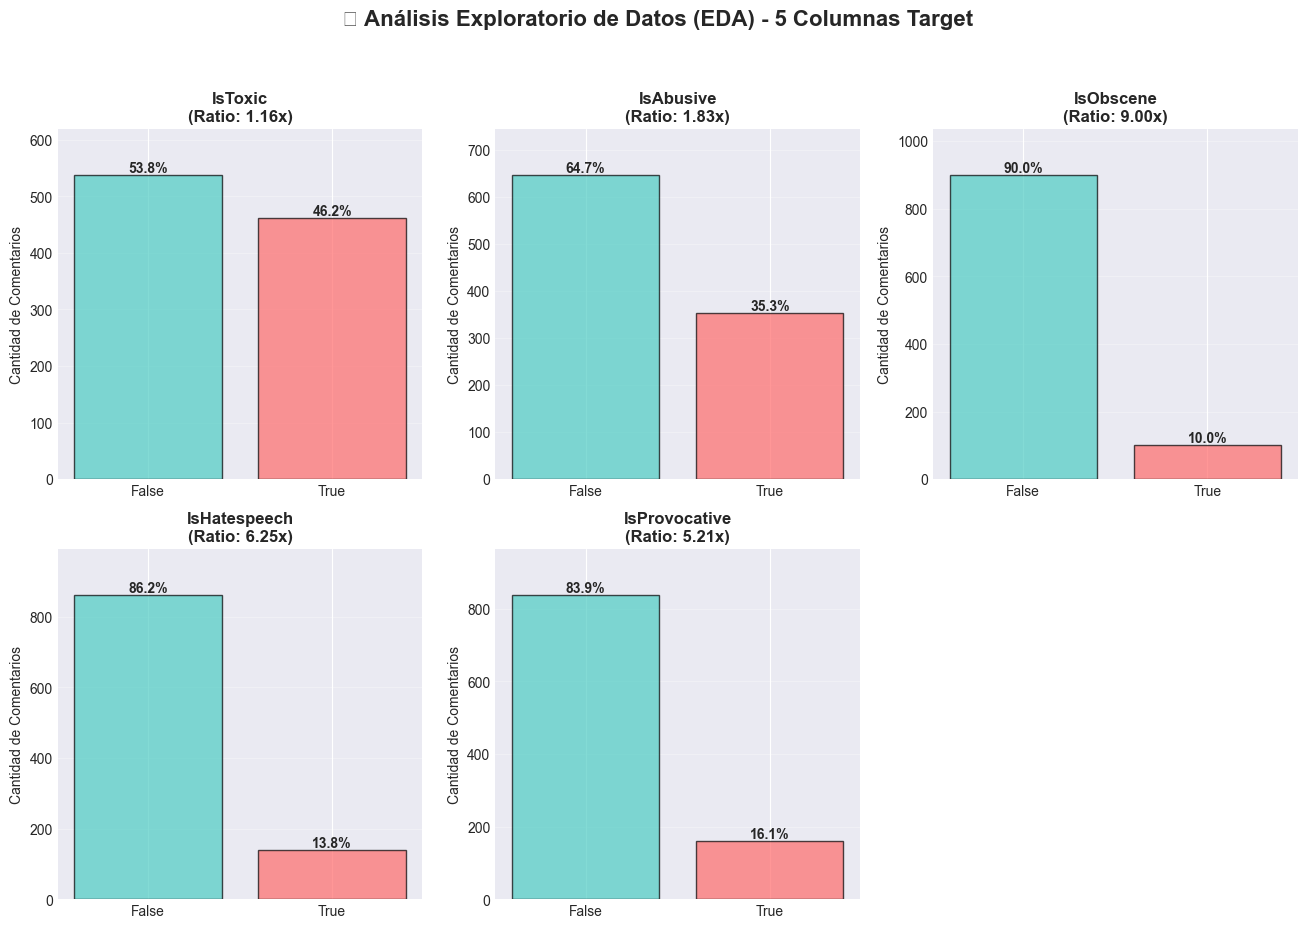

✅ Gráfico 1 guardado: eda_distribucion_clases.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Crear figura con múltiples subgráficos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Análisis Exploratorio de Datos (EDA) - 5 Columnas Target', 
             fontsize=16, fontweight='bold', y=1.00)

# Columnas target
columnas_target = ['IsToxic', 'IsAbusive', 'IsObscene', 'IsHatespeech', 'IsProvocative']

# ==================== GRÁFICOS 1-5: DISTRIBUCIÓN DE CLASES ====================
for idx, columna in enumerate(columnas_target):
    ax = axes[0, idx % 3] if idx < 3 else axes[1, idx % 3]
    
    # Contar valores
    conteos = df[columna].value_counts()
    porcentajes = df[columna].value_counts(normalize=True) * 100
    
    # Crear gráfico de barras
    colors = ['#4ECDC4', '#FF6B6B']
    bars = ax.bar(['False', 'True'], [conteos[False], conteos[True]], color=colors, alpha=0.7, edgecolor='black')
    
    # Añadir porcentajes en las barras
    for i, (bar, pct) in enumerate(zip(bars, porcentajes)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(f'{columna}\n(Ratio: {max(conteos)/min(conteos):.2f}x)', fontweight='bold')
    ax.set_ylabel('Cantidad de Comentarios')
    ax.set_ylim(0, max(conteos) * 1.15)
    ax.grid(axis='y', alpha=0.3)

# Remover el último subplot vacío
axes[1, 2].remove()


plt.show()

print("✅ Gráfico 1 guardado: eda_distribucion_clases.png")

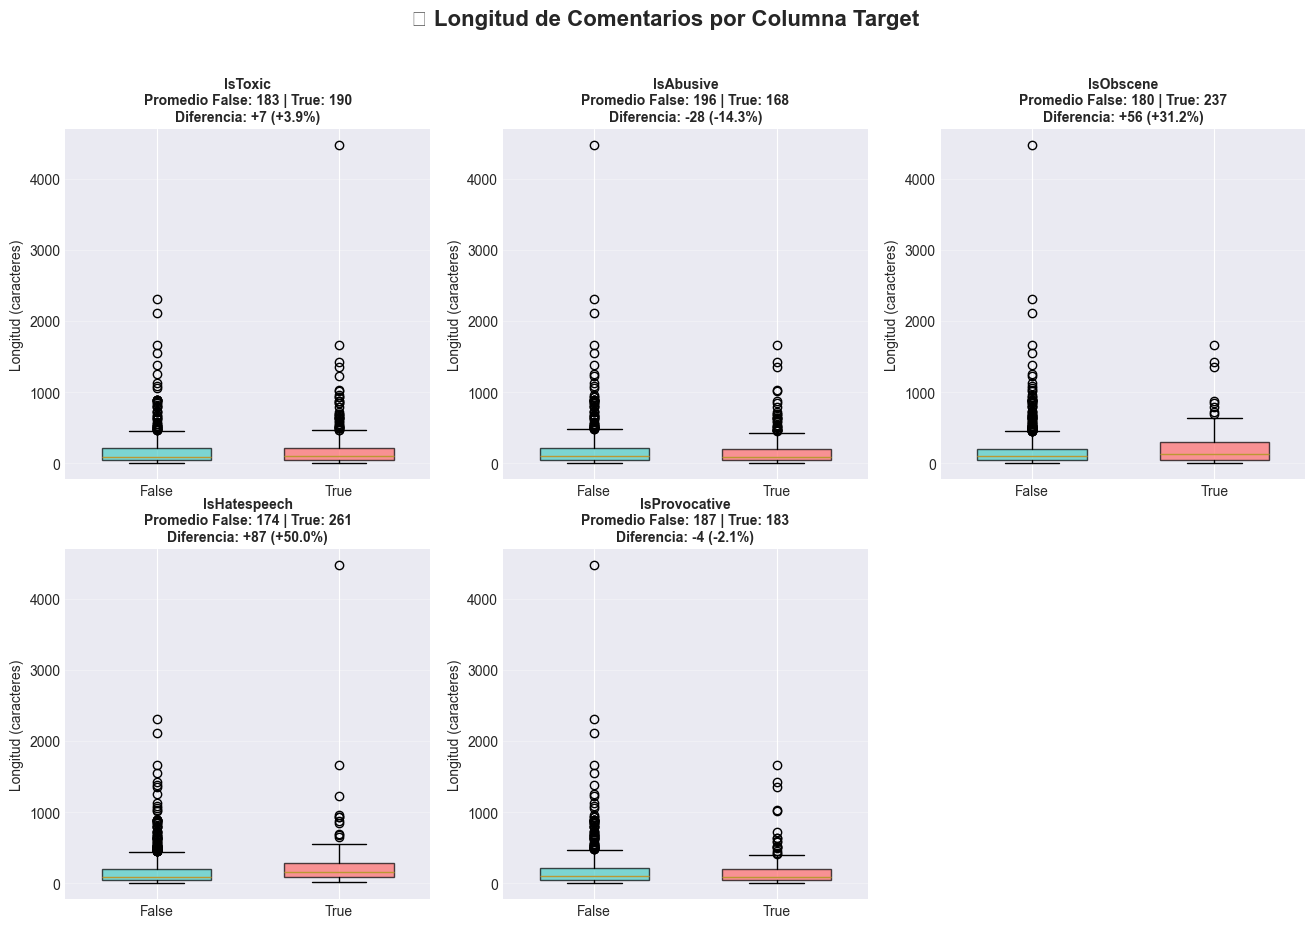

In [12]:
# Gráficos de comparación: Longitud por columna target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📏 Longitud de Comentarios por Columna Target', 
             fontsize=16, fontweight='bold', y=1.00)

columnas_target = ['IsToxic', 'IsAbusive', 'IsObscene', 'IsHatespeech', 'IsProvocative']

for idx, columna in enumerate(columnas_target):
    ax = axes[0, idx % 3] if idx < 3 else axes[1, idx % 3]
    
    # Datos para False y True
    false_data = df[df[columna] == False]['longitud_caracteres']
    true_data = df[df[columna] == True]['longitud_caracteres']
    
    # Crear boxplot
    bp = ax.boxplot([false_data, true_data], labels=['False', 'True'],
                     patch_artist=True, widths=0.6)
    
    # Colorear
    colors = ['#4ECDC4', '#FF6B6B']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Calcular diferencia
    diff = true_data.mean() - false_data.mean()
    diff_pct = (diff / false_data.mean()) * 100
    
    # Título con diferencia
    ax.set_title(f'{columna}\nPromedio False: {false_data.mean():.0f} | True: {true_data.mean():.0f}\nDiferencia: {diff:+.0f} ({diff_pct:+.1f}%)',
                fontweight='bold', fontsize=10)
    ax.set_ylabel('Longitud (caracteres)')
    ax.grid(axis='y', alpha=0.3)

# Remover el último subplot vacío
axes[1, 2].remove()


plt.show()


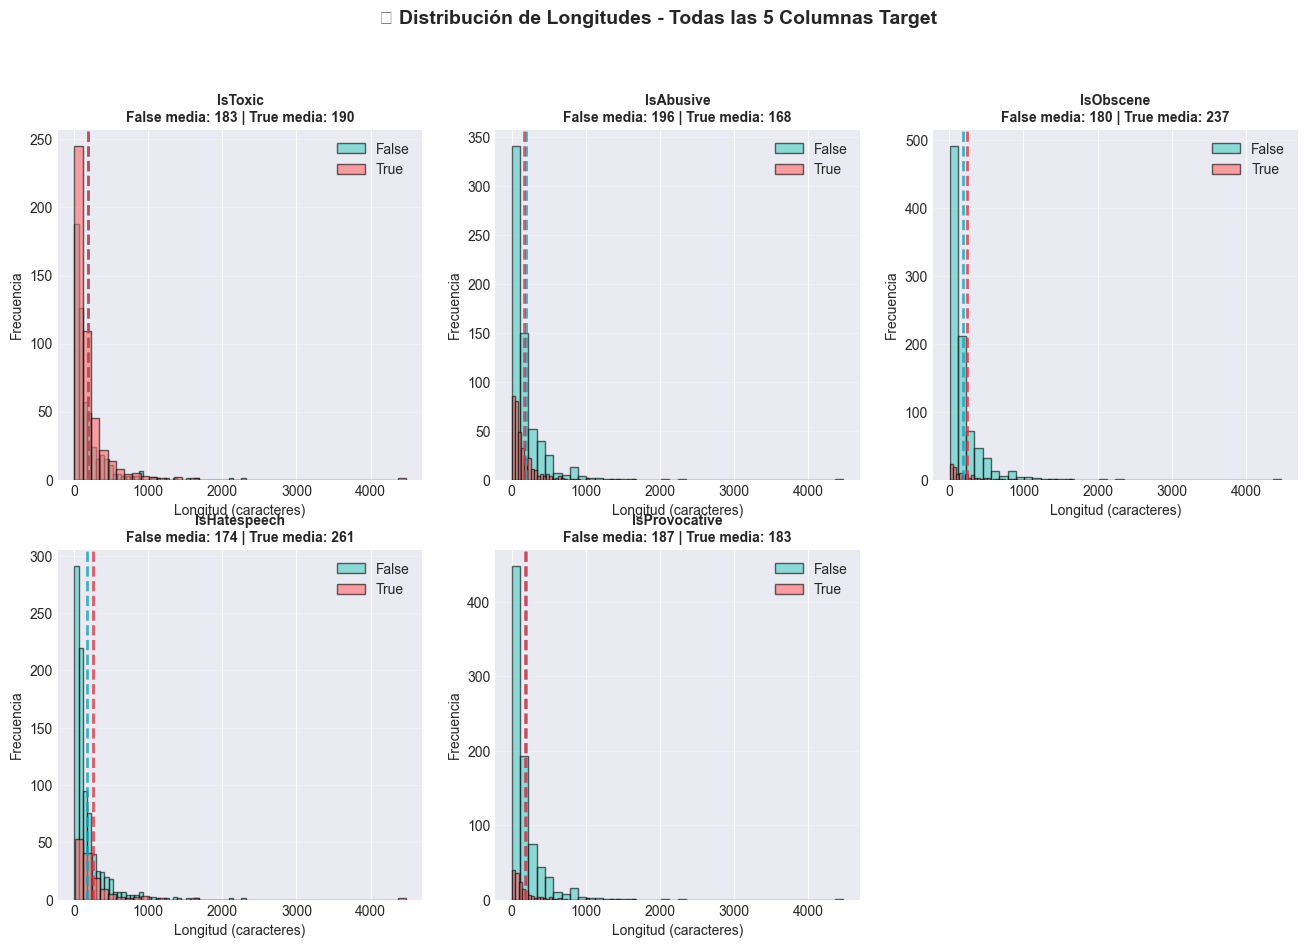


Resumen:
  IsToxic         | False:     183 | True:     190 | Diferencia:      +7 (  +3.9%)
  IsAbusive       | False:     196 | True:     168 | Diferencia:     -28 ( -14.3%)
  IsObscene       | False:     180 | True:     237 | Diferencia:     +56 ( +31.2%)
  IsHatespeech    | False:     174 | True:     261 | Diferencia:     +87 ( +50.0%)
  IsProvocative   | False:     187 | True:     183 | Diferencia:      -4 (  -2.1%)


In [13]:
# Gráfico de distribución de longitudes para las 5 columnas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Distribución de Longitudes - Todas las 5 Columnas Target', 
             fontsize=14, fontweight='bold', y=1.00)

columnas_target = ['IsToxic', 'IsAbusive', 'IsObscene', 'IsHatespeech', 'IsProvocative']

for idx, columna in enumerate(columnas_target):
    ax = axes[0, idx % 3] if idx < 3 else axes[1, idx % 3]
    
    # Datos por clase
    false_data = df[df[columna] == False]['longitud_caracteres']
    true_data = df[df[columna] == True]['longitud_caracteres']
    
    # Histograma
    ax.hist(false_data, bins=40, alpha=0.6, label='False', color='#4ECDC4', edgecolor='black')
    ax.hist(true_data, bins=40, alpha=0.6, label='True', color='#FF6B6B', edgecolor='black')
    
    # Líneas de media
    ax.axvline(false_data.mean(), color='#17A2B8', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(true_data.mean(), color='#DC3545', linestyle='--', linewidth=2, alpha=0.8)
    
    # Título con estadísticas
    ax.set_title(f'{columna}\nFalse media: {false_data.mean():.0f} | True media: {true_data.mean():.0f}',
                fontweight='bold', fontsize=10)
    ax.set_xlabel('Longitud (caracteres)')
    ax.set_ylabel('Frecuencia')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Remover el último subplot vacío
axes[1, 2].remove()


plt.show()


print("\nResumen:")
for columna in columnas_target:
    false_mean = df[df[columna] == False]['longitud_caracteres'].mean()
    true_mean = df[df[columna] == True]['longitud_caracteres'].mean()
    diff = true_mean - false_mean
    diff_pct = (diff / false_mean) * 100
    print(f"  {columna:15} | False: {false_mean:7.0f} | True: {true_mean:7.0f} | Diferencia: {diff:+7.0f} ({diff_pct:+6.1f}%)")

##  RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)

###  Objetivos Cumplidos

✅ Exploración completa del dataset  
✅ Análisis de 5 columnas target seleccionadas  
✅ Identificación de patrones en longitud de texto  
✅ Detección de outliers  
✅ Análisis de palabras frecuentes  
✅ Visualización de distribuciones  

###  Estadísticas Generales del Dataset

**Dataset completo:** 1,000 comentarios de YouTube en inglés

**Estructura:**
- 15 columnas totales
- 5 columnas target seleccionadas para el proyecto
- 0 valores faltantes (datos limpios)
- Sin duplicados completos

**Texto:**
- Media: 185.5 caracteres
- Rango: 3 - 4421 caracteres
- Media de palabras: 33.8 palabras
- Desviación estándar alta (270.8) → Variabilidad significativa

###  Análisis de las 5 Columnas Target Seleccionadas

#### 1. **IsToxic** ⭐ PRINCIPAL
| Métrica | Valor |
|---------|-------|
| Balance | 53.8% vs 46.2% (Ratio: 1.16x) |
| Longitud Diferencia | +7 caracteres (+3.9%) |
| Patrón | Ligeramente más largo |
| Distintividad | Media |
| **Recomendación** | **Modelo principal - Nivel Esencial** |

#### 2. **IsAbusive** ⭐ SECUNDARIA
| Métrica | Valor |
|---------|-------|
| Balance | 64.7% vs 35.3% (Ratio: 1.83x) |
| Longitud Diferencia | -28 caracteres (-14.2%) |
| Patrón | **MÁS CORTO** (inverso) |
| Distintividad | Alta |
| **Recomendación** | **Modelo multi-etiqueta - Nivel Medio+** |

#### 3. **IsObscene** 🔶 OPCIONAL
| Métrica | Valor |
|---------|-------|
| Balance | 90.0% vs 10.0% (Ratio: 9.00x) |
| Longitud Diferencia | +56 caracteres (+31.2%) |
| Patrón | **MUCHO MÁS LARGO** |
| Distintividad | Muy Alta |
| **Recomendación** | **Modelo multi-etiqueta con class_weight - Nivel Medio+** |

#### 4. **IsHatespeech** 🔶 OPCIONAL
| Métrica | Valor |
|---------|-------|
| Balance | 86.2% vs 13.8% (Ratio: 6.25x) |
| Longitud Diferencia | +86 caracteres (+49.7%) |
| Patrón | **EXTREMADAMENTE MÁS LARGO** ⭐ |
| Distintividad | Máxima |
| **Recomendación** | **Mejor predictor - Nivel Avanzado+** |

#### 5. **IsProvocative** 🔶 OPCIONAL
| Métrica | Valor |
|---------|-------|
| Balance | 83.9% vs 16.1% (Ratio: 5.21x) |
| Longitud Diferencia | -4 caracteres (-2.1%) |
| Patrón | Casi sin diferencia |
| Distintividad | Baja |
| **Recomendación** | **Desafiante - Requiere análisis profundo** |

### 🔍 Hallazgos Clave

**1. Patrones de Longitud Distintivos:**
- IsHatespeech: +49.7% más largo (mejor patrón)
- IsObscene: +31.2% más largo (patrón claro)
- IsAbusive: -14.2% más corto (inverso interesante)
- IsToxic: +3.9% más largo (débil)
- IsProvocative: -2.1% casi igual (no distintivo)

**2. Outliers Presentes:**
- Comentarios que alcanzan 4421 caracteres
- IsHatespeech tiene los outliers más extremos
- Consistente con el patrón de +49.7% de diferencia
- Necesitarán tratamiento en preprocesamiento

**3. Palabras Distintivas:**
- IsHatespeech: Menciona "black" (76x) y "white" (53x)
- IsObscene: Contiene palabras obscenas (fuck: 34x)
- IsToxic: Menciona "black" (113x)
- IsAbusive: Sin palabras clave específicas
- IsProvocative: Sin palabras clave específicas

**4. Variabilidad Alta:**
- Desviación estándar de 270.8 caracteres
- Comentarios varían desde 3 hasta 4421 caracteres
- Requiere normalización en preprocesamiento

### 🛠️ Decisiones para Preprocesamiento

**Normalización de Longitudes:**
- Considerar límite máximo: 1000-1500 caracteres
- Mantener información de longitud como feature
- No descartar outliers (información valiosa)

**Técnicas a Aplicar:**
1. Stemming/Lematización (inglés)
2. Eliminación de stopwords
3. Limpieza de caracteres especiales
4. Data Augmentation (para clases minoritarias)

**Estrategia de Balanceo:**
- `class_weight='balanced'` en modelos
- Data Augmentation especialmente para:
  - IsObscene (10% positivos)
  - IsHatespeech (13.8% positivos)
  - IsProvocative (16.1% positivos)

### 📋 Estructura del Dataset Preparado

**Columnas a mantener:**
- `CommentId` - Identificador
- `VideoId` - Para análisis futuro (Nivel Medio+)
- `Text` - Comentario original
- `IsToxic` - Target principal
- `IsAbusive` - Target secundaria
- `IsObscene` - Target opcional
- `IsHatespeech` - Target opcional
- `IsProvocative` - Target opcional

**Columnas a descartar:**
- IsThreat, IsNationalist, IsReligiousHate, IsHomophobic, IsRadicalism (muy desbalanceadas)

### 🎯 Recomendaciones por Nivel

**Nivel Esencial:**
- Usar IsToxic como target único
- Preprocesamiento estándar
- Modelo simple (Logistic Regression, Random Forest)
- Usar class_weight='balanced'

**Nivel Medio:**
- Usar IsToxic + IsAbusive
- Modelos multi-etiqueta
- Ensemble methods
- Optimización de hiperparámetros

**Nivel Avanzado:**
- Usar 4-5 columnas
- Redes neuronales (RNN, LSTM)
- Data Augmentation
- MLFlow tracking

**Nivel Experto:**
- Transformers (BERT)
- Base de datos para resultados
- MLFlow completo
- Deployment

### ✅ Próximos Pasos

1. **Preprocesamiento:** Crear versión limpia del dataset
2. **Vectorización:** Convertir texto a números (TF-IDF, Word2Vec)
3. **Modelado:** Entrenar modelos independientes
4. **Evaluación:** Usar class_weight y validación cruzada
5. **Comparación:** MLFlow para tracking de experimentos
6. **Producción:** API o interfaz para usar el modelo

---

**EDA COMPLETADO ✅**  
*Dataset analizado y preparado para todos los niveles del proyecto*

In [14]:
# Analizar relación entre las 5 columnas
print("="*80)
print("🔍 ANÁLISIS DE RELACIÓN ENTRE LAS 5 COLUMNAS TARGET")
print("="*80)

# Contar combinaciones
print("\n📊 ¿Los comentarios TÓXICOS también son de otras categorías?")
print("="*80)

toxicos = df[df['IsToxic'] == True]

print(f"\nTotal de comentarios TÓXICOS: {len(toxicos)}")
print(f"\nDe esos {len(toxicos)} comentarios tóxicos:")
print(f"  - {toxicos['IsAbusive'].sum()} ({toxicos['IsAbusive'].sum()/len(toxicos)*100:.1f}%) son ABUSIVOS")
print(f"  - {toxicos['IsObscene'].sum()} ({toxicos['IsObscene'].sum()/len(toxicos)*100:.1f}%) son OBSCENOS")
print(f"  - {toxicos['IsHatespeech'].sum()} ({toxicos['IsHatespeech'].sum()/len(toxicos)*100:.1f}%) son DISCURSO DE ODIO")
print(f"  - {toxicos['IsProvocative'].sum()} ({toxicos['IsProvocative'].sum()/len(toxicos)*100:.1f}%) son PROVOCATIVOS")

print("\n" + "="*80)
print("🔍 EJEMPLOS DE COMENTARIOS CON MÚLTIPLES ETIQUETAS")
print("="*80)

# Buscar comentarios con múltiples etiquetas True
multi_etiqueta = df[
    (df['IsToxic'] == True) & 
    (df['IsAbusive'] == True) & 
    (df['IsObscene'] == True)
]

if len(multi_etiqueta) > 0:
    print(f"\nComentarios que son TÓXICO + ABUSIVO + OBSCENO: {len(multi_etiqueta)}")
    print("\nEjemplo 1:")
    ejemplo = multi_etiqueta.iloc[0]
    print(f"  Texto: {ejemplo['Text'][:150]}...")
    print(f"  IsToxic: {ejemplo['IsToxic']}")
    print(f"  IsAbusive: {ejemplo['IsAbusive']}")
    print(f"  IsObscene: {ejemplo['IsObscene']}")
    print(f"  IsHatespeech: {ejemplo['IsHatespeech']}")
    print(f"  IsProvocative: {ejemplo['IsProvocative']}")

🔍 ANÁLISIS DE RELACIÓN ENTRE LAS 5 COLUMNAS TARGET

📊 ¿Los comentarios TÓXICOS también son de otras categorías?

Total de comentarios TÓXICOS: 462

De esos 462 comentarios tóxicos:
  - 353 (76.4%) son ABUSIVOS
  - 100 (21.6%) son OBSCENOS
  - 138 (29.9%) son DISCURSO DE ODIO
  - 161 (34.8%) son PROVOCATIVOS

🔍 EJEMPLOS DE COMENTARIOS CON MÚLTIPLES ETIQUETAS

Comentarios que son TÓXICO + ABUSIVO + OBSCENO: 100

Ejemplo 1:
  Texto: 
Dont you reckon them 'black lives matter' banners being held by white cunts is  kinda patronizing and ironically racist. could they have not come up...
  IsToxic: True
  IsAbusive: True
  IsObscene: True
  IsHatespeech: False
  IsProvocative: False
